In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('economic_index.csv');
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
df.drop(columns=['Unnamed: 0' , 'year' , 'month'] , inplace= True )

In [5]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


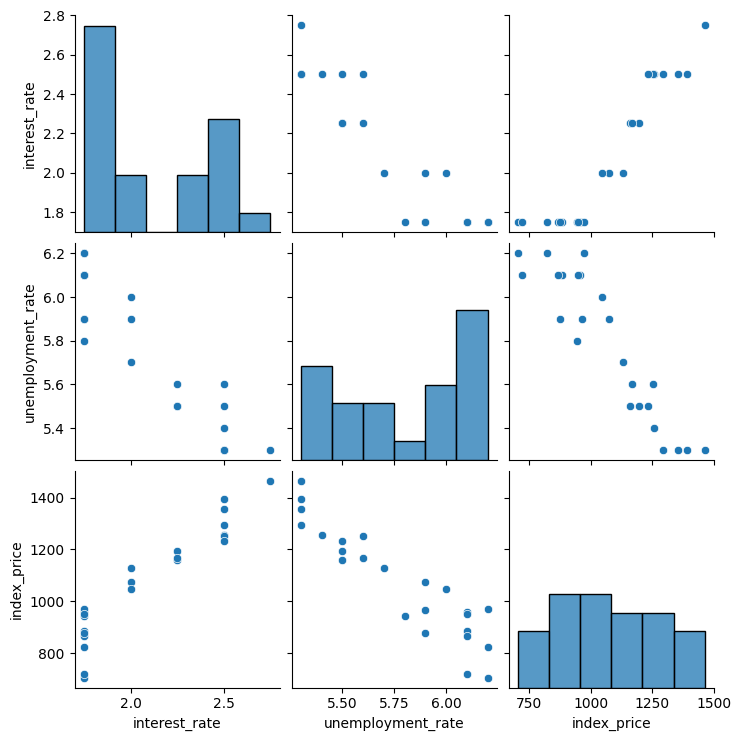

In [6]:
sns.pairplot(df)

In [7]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


chech if null

In [8]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [9]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

spllit the data

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,  X_test , y_train , y_test = train_test_split(X,y,test_size=0.25 , random_state= 42)

<Axes: xlabel='index_price', ylabel='interest_rate'>

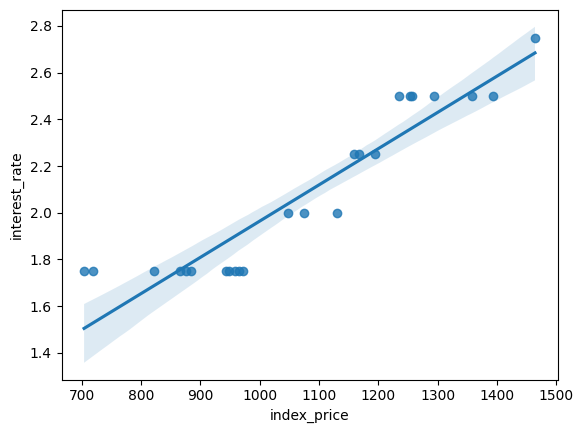

In [22]:
sns.regplot(x=df['index_price'], y=df['interest_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

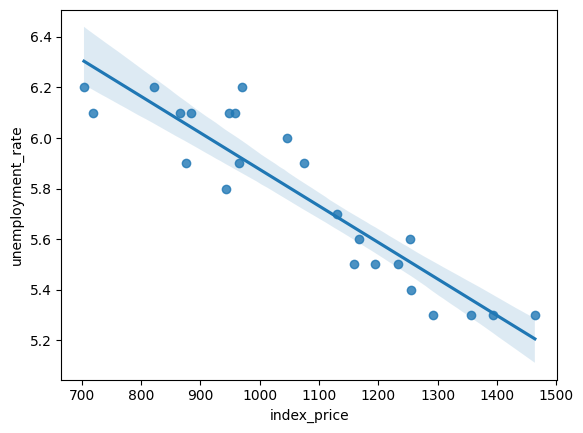

In [23]:
sns.regplot(x=df['index_price'], y=df['unemployment_rate'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

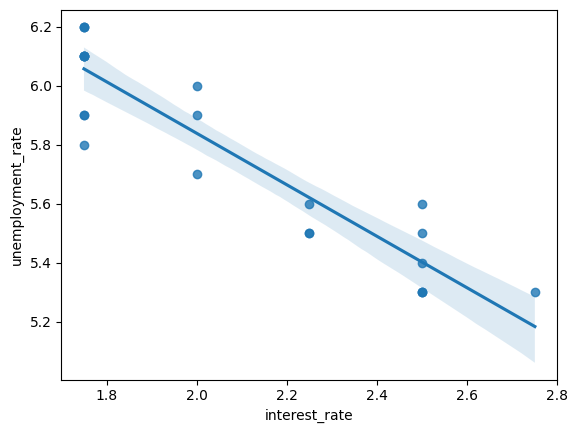

In [ ]:
sns.regplot(x=df[''], y=df['unemployment_rate'])

Standerd Scaler

In [25]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

Make a model

In [12]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()

In [13]:
model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Cross validaton

### Core Concept:
A resampling technique used to evaluate how a machine learning model generalizes to an independent, unseen dataset. It ensures every data point is used for both training and testing.

### Key Steps (K-Fold CV):
Split: Divide data into $k$ equal groups (folds).Iterate: Train on $k-1$ folds and test on the remaining 1 fold.Repeat: Cycle until every fold has acted as the test set exactly once.Average: Combine the performance metrics from all $k$ runs for a final score.

### Why Use It?

Reduces Bias: Prevents getting a "lucky" or "unlucky" train-test split.

Maximizes Data: Useful for smaller datasets where you can't afford a large separate test set.

Detects Overfitting: Provides a more realistic estimate of real-world performance.


### Common Types:K-Fold: 
Standard approach (usually $k=5$ or $10$).Stratified K-Fold: Keeps the same percentage of each class in every fold (best for imbalanced data).LOOCV (Leave-One-Out): $k$ equals the number of data points. High computation, low bias.Time-Series Split: Respects chronological order (trains on past, tests on future).

In [27]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(model, X_train , y_train, scoring= 'neg_mean_squared_error' , cv = 5)

In [29]:
np.mean(validation_score)

np.float64(-5649.115244350768)

In [14]:
y_pred = model.predict(X_test)

In [15]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [16]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score 

In [34]:
mse = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test , y_pred)
print(mse)
print(mae)
print(rmse)
print(r2)
print('adjusted R-squared')
print(1 - (1-r2)*(len(y_test)-1) / (len(y_test) -X_test.shape[1] -1))

5793.762887712554
59.935781523235505
76.11677139574796
0.827897809145715
adjusted R-squared
0.7131630152428583


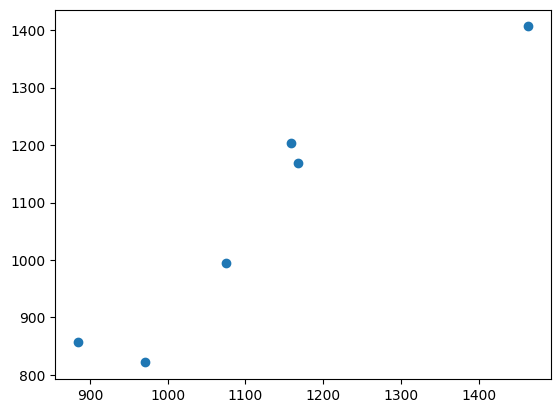

In [35]:
plt.scatter(y_test , y_pred)

In [37]:
reseduals = y_test - y_pred
reseduals

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64

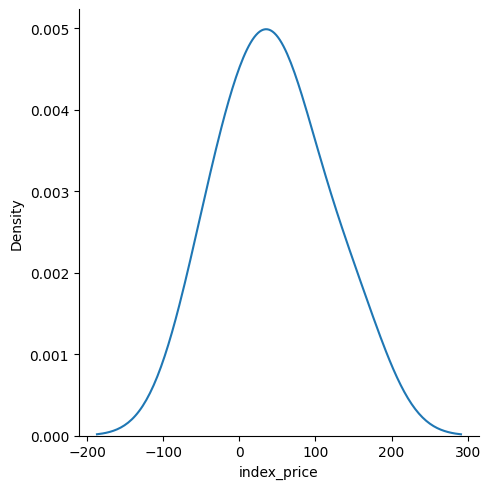

In [39]:
#plot reseduals
sns.displot(reseduals ,kind='kde')

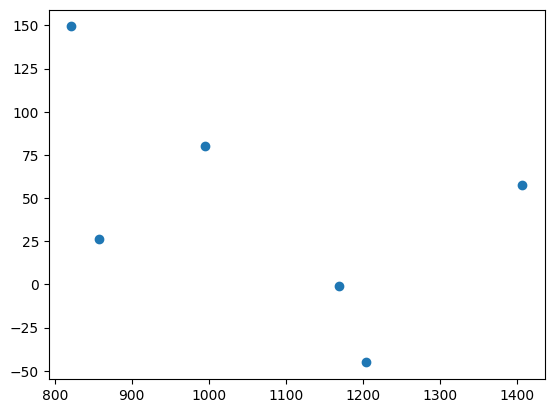

In [40]:
## scatter plot with repect to prediction and residuals
plt.scatter(y_pred  , reseduals)

#### As the data is distributed uniformly this means every thing is good